In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.dates import DateFormatter, HourLocator
from scipy.fft import rfft2, fftfreq, rfftfreq

SCRATCHDIR = "/glade/derecho/scratch/nforcone"

# high model top
RUNDIR_HIGH_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_fadiab_p_pert_isothermal275K/run"
FILENAME_HIGH_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

# 12km model top
RUNDIR_LOW_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_400m_fadiab_p_pert_isothermal275K/run"
FILENAME_LOW_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_400m_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

ds_high_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_HIGH_TOP, FILENAME_HIGH_TOP), decode_cf=False)
ds_low_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_LOW_TOP, FILENAME_LOW_TOP), decode_cf=False)

In [2]:
def Hovmoller(MyAx, field_DataArray, lat_val, MyCMAP, MyNorm):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, norm=MyNorm)
    cb = plt.colorbar(CF, ax=MyAx)
    cb.set_label(r'Zonal Wind Speed [$m s^{-1}$]', size=labelsize)
    plt.xticks(rotation=45, size='xx-small')
    MyAx.set_xticks(np.arange(0, 361, step=10))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis.set_major_locator(HourLocator(interval=3))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.set_title(f"lat={field.lat:.2f}", size=labelsize)

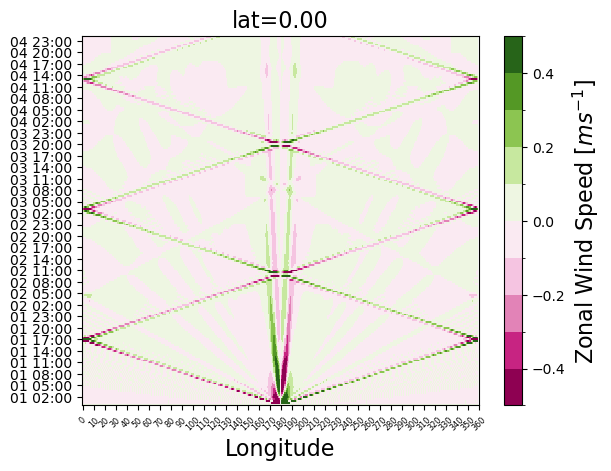

In [3]:
# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax, ds_high_top.U850, lat_value, cmap, norm)

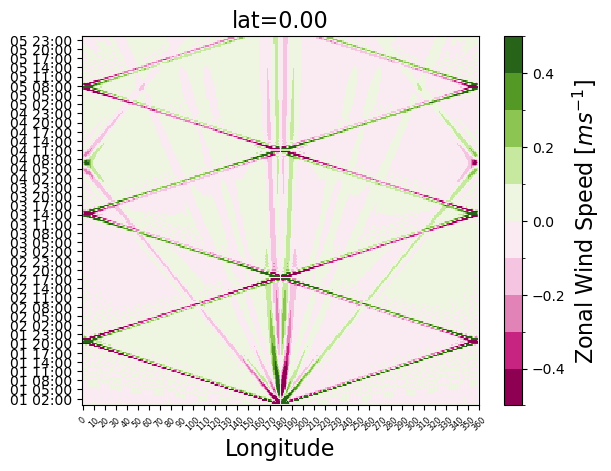

In [4]:
# figure and axes
plt.figure(2)
hovmoller_ax_low = plt.axes()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax_low, ds_low_top.U850, lat_value, cmap, norm)

Num time points:  193
Num grid points:  360
signal_fft.shape:  (193, 181)


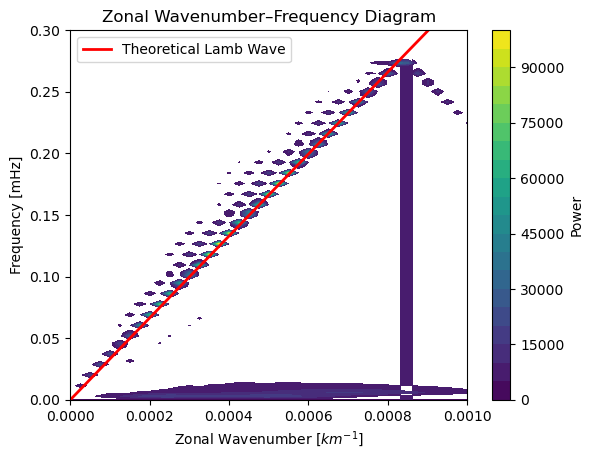

In [5]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_high_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1

# Lamb wave dispersion relationship
omega = cs * wavenumber * 1e3         # mHz

# plot
plt.figure(3)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

Num time points:  241
Num grid points:  360
signal_fft.shape:  (241, 181)


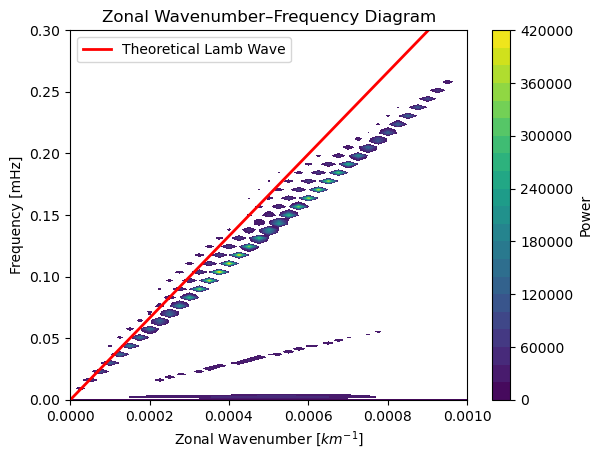

In [6]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_low_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1

# Lamb wave dispersion relationship
omega = cs * wavenumber * 1e3         # mHz

# plot
plt.figure(4)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

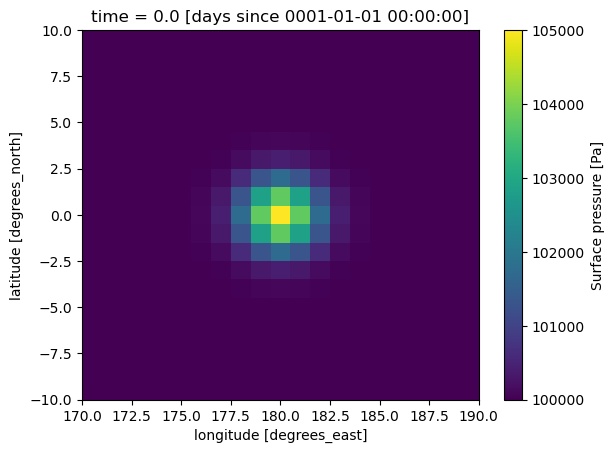

In [7]:
ds_high_top['PS'][0,:,:].plot(xlim=(170, 190), ylim=(-10, 10))

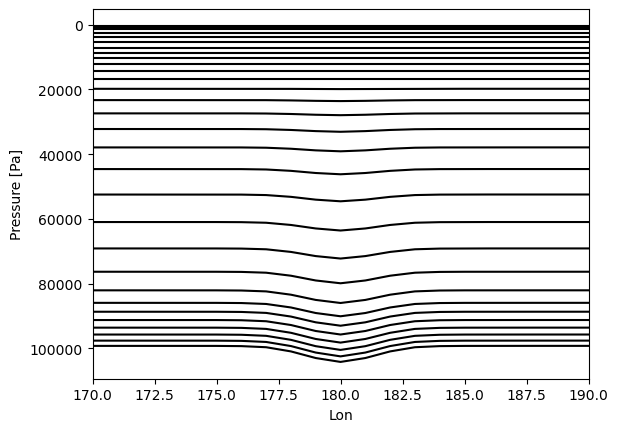

In [8]:
PS_lat0 = ds_high_top['PS'].sel(time=0, lat=0.0)
lon = ds_high_top.lon

# high
hyam_high = ds_high_top['hyam']
hybm_high = ds_high_top['hybm']
lev_high = hyam_high * 100000 + hybm_high * PS_lat0

plt.figure(6)
lev_ax_high = plt.axes()
lev_ax_high.plot(lon, lev_high.values.T, 'k')
lev_ax_high.set_xlim(170, 190)
lev_ax_high.set_xlabel('Lon')
lev_ax_high.set_ylabel('Pressure [Pa]')
lev_ax_high.invert_yaxis()

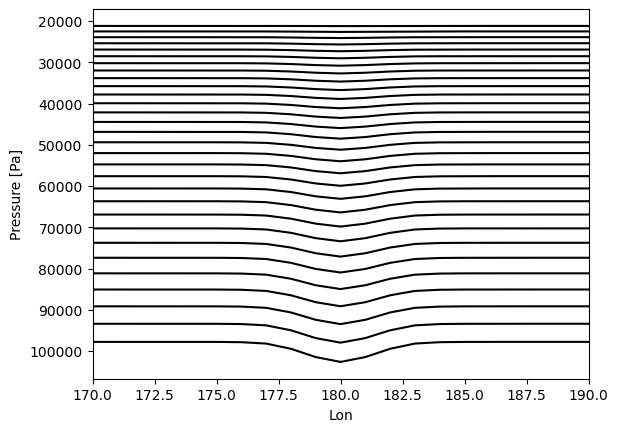

In [9]:
PS_lat0 = ds_low_top['PS'].sel(time=0, lat=0.0)
lon = ds_low_top.lon

# low
hyam_low = ds_low_top['hyam']
hybm_low = ds_low_top['hybm']
lev_low = hyam_low * 100000 + hybm_low * PS_lat0

plt.figure(7)
lev_ax_low = plt.axes()
lev_ax_low.plot(lon, lev_low.values.T, 'k')
lev_ax_low.set_xlim(170, 190)
lev_ax_low.set_xlabel('Lon')
lev_ax_low.set_ylabel('Pressure [Pa]')
lev_ax_low.invert_yaxis()